# Demo 5 - Purity, Coherence, Entanglement & Multiqubit Systems

### Education Series · Quantum Computing

---

In the previous notebook, we built the **density matrix** $\rho$ and the **Bloch Sphere**, and saw how a single qubit's state can be *pure* (on the surface) or *mixed* (inside). This notebook takes that machinery deeper and then opens it up to **two qubits**, where the most distinctively quantum phenomenon - **entanglement** - lives.

**The thread we are following.** Throughout this course one idea recurs: *indistinguishable alternatives interfere; probabilities are squared magnitudes of amplitudes.* In the double-slit and Stern–Gerlach (SG) experiments, **interference disappears the moment which-path information exists.** In this notebook we will see that *which-path information becoming available* is **exactly entanglement with another system**, and that the loss of interference is the **decay of off-diagonal coherences** in the reduced density matrix. Coherence, entanglement, and decoherence turn out to be three views of one phenomenon.

**Roadmap**

| § | Topic | Key object |
|---|-------|-----------|
| 1 | Density matrix, deeper | ensembles, validity, $\langle A\rangle=\mathrm{Tr}(\rho A)$, ambiguity |
| 2 | **Purity** | $\mathrm{Tr}(\rho^2)$, Bloch radius, von Neumann entropy |
| 3 | **Coherence** | off-diagonals, basis dependence, dephasing |
| 4 | **Multiqubit systems** | tensor / Kronecker products |
| 5 | **Entanglement** | partial trace, reduced states, Schmidt decomposition |
| 6 | Synthesis | *decoherence = entanglement with the environment* |
| 7 | Exercises (★–★★★) | with collapsible solutions |

> **Run order matters.** Execute the cells top to bottom (`Runtime ▸ Run all` in Colab). Every section reuses a small toolkit defined once below. The library is intentionally **NumPy + Matplotlib only** (plus `ipywidgets` for the sliders) so it runs anywhere with zero setup.

## 0 · Setup and a reusable toolkit

We fix a random seed so every in-class demonstration is reproducible, and we collect the core helper functions in **one place**. These are the same primitives from Notebook 3, extended with a few new ones (`purity`, `von_neumann_entropy`, `l1_coherence`) that we will lean on throughout. Later notebooks (Bell inequalities, CHSH) are designed to import this same toolkit unchanged.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

np.random.seed(42)          # reproducible demos
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 110

# ---- single-qubit basics -------------------------------------------------
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]],   dtype=complex)   # Pauli-X  (sigma_x)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)  # Pauli-Y  (sigma_y)
Z  = np.array([[1, 0], [0, -1]],  dtype=complex)   # Pauli-Z  (sigma_z)

ket0 = np.array([[1], [0]], dtype=complex)
ket1 = np.array([[0], [1]], dtype=complex)
ketp = (ket0 + ket1) / np.sqrt(2)   # |+>
ketm = (ket0 - ket1) / np.sqrt(2)   # |->
keti = (ket0 + 1j*ket1) / np.sqrt(2)  # |+i>

print("Toolkit loaded. Pauli matrices and basis kets ready.")

Toolkit loaded. Pauli matrices and basis kets ready.


In [ ]:
# ---- core density-matrix functions --------------------------------------
def density_from_state(psi):
    """Pure-state density matrix rho = |psi><psi| from a (column) state vector."""
    psi = np.asarray(psi, dtype=complex).reshape(-1, 1)
    psi = psi / np.linalg.norm(psi)          # be safe: normalise
    return psi @ psi.conj().T

def bloch_vector(rho):
    """Bloch vector r = (<X>, <Y>, <Z>) of a single-qubit density matrix."""
    return np.array([np.real(np.trace(rho @ P)) for P in (X, Y, Z)])

def purity(rho):
    """Purity gamma = Tr(rho^2), a real number in [1/d, 1]."""
    return float(np.real(np.trace(rho @ rho)))

def von_neumann_entropy(rho, base=2):
    """S(rho) = -Tr(rho log rho) via eigen-decomposition (no scipy)."""
    ev = np.linalg.eigvalsh(rho)             # real eigenvalues (Hermitian)
    ev = ev[ev > 1e-12]                       # drop zeros to avoid log(0)
    return float(-np.sum(ev * (np.log(ev) / np.log(base))))

def l1_coherence(rho):
    """l1-norm of coherence: sum of |off-diagonal| entries (basis-dependent)."""
    return float(np.sum(np.abs(rho)) - np.sum(np.abs(np.diag(rho))))

def expectation(rho, A):
    """Expectation value <A> = Tr(rho A)."""
    return np.real(np.trace(rho @ A))

print("Core functions: density_from_state, bloch_vector, purity,")
print("von_neumann_entropy, l1_coherence, expectation")

Core functions: density_from_state, bloch_vector, purity,
von_neumann_entropy, l1_coherence, expectation


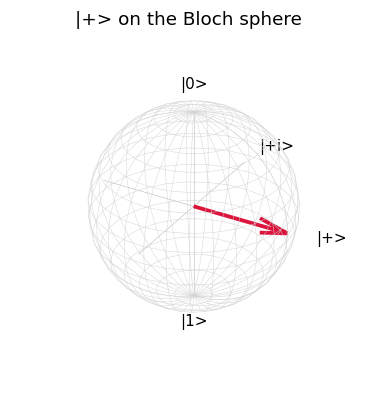

In [ ]:
# ---- a small Bloch-sphere drawing helper (reused from Notebook 3) --------
def plot_bloch(r, ax=None, title="", color="crimson"):
    """Draw a Bloch vector r=(x,y,z) inside a wireframe unit sphere."""
    if ax is None:
        fig = plt.figure(figsize=(4.2, 4.2))
        ax = fig.add_subplot(111, projection="3d")
    u = np.linspace(0, 2*np.pi, 30); v = np.linspace(0, np.pi, 18)
    ax.plot_wireframe(np.outer(np.cos(u), np.sin(v)),
                      np.outer(np.sin(u), np.sin(v)),
                      np.outer(np.ones_like(u), np.cos(v)),
                      color="lightgray", linewidth=0.3)
    ax.quiver(0, 0, 0, r[0], r[1], r[2], color=color, linewidth=2.5)
    for axis in ((1,0,0),(0,1,0),(0,0,1)):
        ax.plot([-axis[0],axis[0]], [-axis[1],axis[1]], [-axis[2],axis[2]],
                color="gray", linewidth=0.4, alpha=0.5)
    ax.text(0,0,1.25,"|0>", ha="center"); ax.text(0,0,-1.35,"|1>", ha="center")
    ax.text(1.3,0,0,"|+>"); ax.text(0,1.3,0,"|+i>")
    ax.set_xlim([-1,1]); ax.set_ylim([-1,1]); ax.set_zlim([-1,1])
    ax.set_box_aspect([1,1,1]); ax.set_title(title); ax.set_axis_off()
    return ax

# quick smoke test
plot_bloch(bloch_vector(density_from_state(ketp)), title="|+> on the Bloch sphere")
plt.show()

## 1 · The density matrix, revisited

### 1.1 From state vectors to ensembles

A state vector $|\psi\rangle$ describes a system we know *as completely as quantum mechanics allows*. But two distinct kinds of uncertainty arise in practice:

- **Quantum** uncertainty - even for a perfectly known $|\psi\rangle$, measurement outcomes are random.
- **Classical** uncertainty - we may only know that the system is $|\psi_i\rangle$ *with probability* $p_i$ (an imperfect source, a thermal beam, a subsystem of a larger system).

The **density matrix** captures both at once. For an **ensemble** $\{p_i, |\psi_i\rangle\}$,

$$\rho \;=\; \sum_i p_i\, |\psi_i\rangle\langle\psi_i|, \qquad p_i \ge 0,\quad \sum_i p_i = 1.$$

A **pure** state is the special case of a single term, $\rho = |\psi\rangle\langle\psi|$. Anything else is **mixed**.

### 1.2 What makes a matrix a valid state

$\rho$ is a legitimate density matrix **iff** it is

1. **Hermitian:** $\rho = \rho^\dagger$  (real eigenvalues = real probabilities),
2. **Positive semidefinite:** $\langle\phi|\rho|\phi\rangle \ge 0\ \forall|\phi\rangle$  (no negative probabilities),
3. **Unit trace:** $\mathrm{Tr}\,\rho = 1$  (probabilities sum to one).

### 1.3 Everything observable is $\mathrm{Tr}(\rho A)$

The expectation value of any observable $A$ is

$$\boxed{\;\langle A\rangle = \mathrm{Tr}(\rho A)\;}$$

and a measurement outcome with projector $P_m$ occurs with probability $p(m)=\mathrm{Tr}(P_m\rho)$, leaving the state $\rho \to P_m\rho P_m / p(m)$. Unitary evolution acts as $\rho \to U\rho U^\dagger$.

In [ ]:
def is_valid_density(rho, tol=1e-9, verbose=True):
    """Check the three defining properties of a density matrix."""
    herm = np.allclose(rho, rho.conj().T, atol=tol)
    tr1  = np.isclose(np.real(np.trace(rho)), 1.0, atol=tol)
    ev   = np.linalg.eigvalsh((rho + rho.conj().T)/2)   # symmetrise for safety
    psd  = bool(np.all(ev >= -tol))
    if verbose:
        print(f"  Hermitian      : {herm}")
        print(f"  Unit trace     : {tr1}  (Tr = {np.real(np.trace(rho)):.4f})")
        print(f"  Positive semidef: {psd}  (eigenvalues = {np.round(ev,4)})")
    return herm and tr1 and psd

print("A genuine mixed state  rho = 0.7|0><0| + 0.3|1><1| :")
good = 0.7*density_from_state(ket0) + 0.3*density_from_state(ket1)
print("  valid?", is_valid_density(good), "\n")

print("An impostor (Hermitian, unit trace, but NOT positive):")
bad = np.array([[1.4, 0.0], [0.0, -0.4]], dtype=complex)
print("  valid?", is_valid_density(bad))

A genuine mixed state  rho = 0.7|0><0| + 0.3|1><1| :
  Hermitian      : True
  Unit trace     : True  (Tr = 1.0000)
  Positive semidef: True  (eigenvalues = [0.3 0.7])
  valid? True 

An impostor (Hermitian, unit trace, but NOT positive):
  Hermitian      : True
  Unit trace     : True  (Tr = 1.0000)
  Positive semidef: False  (eigenvalues = [-0.4  1.4])
  valid? False


### 1.4 The same $\rho$, two different stories: *ensemble ambiguity*

Here is a fact that quietly demolishes a common misconception. Consider two completely different physical preparations:

- **A:** flip a fair coin; send $|0\rangle$ or $|1\rangle$.
- **B:** flip a fair coin; send $|+\rangle$ or $|-\rangle$.

These sound like opposite experiments. Yet they produce the **identical** density matrix $\tfrac12 I$ - and therefore are **experimentally indistinguishable by any measurement whatsoever.** The density matrix contains *everything physically meaningful*; the "which ensemble" question has no observable answer.

In [ ]:
rho_A = 0.5*density_from_state(ket0) + 0.5*density_from_state(ket1)
rho_B = 0.5*density_from_state(ketp) + 0.5*density_from_state(ketm)

print("Ensemble A  (mix of |0>,|1>):\n", rho_A)
print("\nEnsemble B  (mix of |+>,|->):\n", rho_B)
print("\nIdentical?", np.allclose(rho_A, rho_B), " ... and both equal I/2:",
      np.allclose(rho_A, I2/2))
print("\n=> No measurement can tell A from B. The density matrix is the complete state.")

Ensemble A  (mix of |0>,|1>):
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

Ensemble B  (mix of |+>,|->):
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

Identical? True  ... and both equal I/2: True

=> No measurement can tell A from B. The density matrix is the complete state.


> **Misconception alert.** A maximally mixed state $\tfrac12 I$ is **not** a superposition. It is a *classical coin flip* over outcomes. The superposition $|+\rangle$ is a definite, pure state pointing along $+x$; the mixture $\tfrac12 I$ points nowhere. We'll make this geometric in §2.

## 2 · Purity - how mixed is a state?

### 2.1 Definition and range

The single number that quantifies mixedness is the **purity**

$$\gamma \;=\; \mathrm{Tr}(\rho^2) \;=\; \sum_i \lambda_i^2,$$

where $\lambda_i$ are the eigenvalues of $\rho$. For a $d$-dimensional system,

$$\frac{1}{d} \;\le\; \mathrm{Tr}(\rho^2) \;\le\; 1.$$

- $\mathrm{Tr}(\rho^2) = 1 \iff \rho$ is **pure** ($\rho^2=\rho$, one eigenvalue $1$, rest $0$).
- $\mathrm{Tr}(\rho^2) = 1/d \iff \rho$ is **maximally mixed** ($\rho = I/d$).

### 2.2 Purity *is* the Bloch radius (for a qubit)

Write any qubit state as $\rho = \tfrac12\big(I + \mathbf{r}\cdot\boldsymbol\sigma\big)$ with Bloch vector $\mathbf r=(\langle X\rangle,\langle Y\rangle,\langle Z\rangle)$. A two-line computation gives

$$\boxed{\;\mathrm{Tr}(\rho^2) = \tfrac12\big(1 + |\mathbf r|^2\big)\;}$$

So purity is **literally the squared radius** in the Bloch ball:

| location | $|\mathbf r|$ | purity | meaning |
|---|---|---|---|
| surface | $1$ | $1$ | pure |
| interior | $0<|\mathbf r|<1$ | $(1+|\mathbf r|^2)/2$ | mixed |
| centre | $0$ | $1/2$ | maximally mixed |

In [ ]:
# Verify Tr(rho^2) = (1+|r|^2)/2 on 5000 random qubit states
def random_density_qubit():
    A = np.random.randn(2,2) + 1j*np.random.randn(2,2)
    rho = A @ A.conj().T
    return rho / np.trace(rho)

max_err = 0.0
for _ in range(5000):
    rho = random_density_qubit()
    r = bloch_vector(rho)
    max_err = max(max_err, abs(purity(rho) - 0.5*(1+np.dot(r,r))))
print(f"Identity  Tr(rho^2) = (1+|r|^2)/2  verified.  max error = {max_err:.2e}")

for name, rho in [("|+>  (pure, surface)", density_from_state(ketp)),
                  ("0.85|0>+0.15|1> mix ", 0.85*density_from_state(ket0)+0.15*density_from_state(ket1)),
                  ("I/2  (max. mixed)   ", I2/2)]:
    r = bloch_vector(rho)
    print(f"{name}:  |r|={np.linalg.norm(r):.3f}   purity={purity(rho):.3f}")

Identity  Tr(rho^2) = (1+|r|^2)/2  verified.  max error = 3.33e-16
|+>  (pure, surface):  |r|=1.000   purity=1.000
0.85|0>+0.15|1> mix :  |r|=0.700   purity=0.745
I/2  (max. mixed)   :  |r|=0.000   purity=0.500


### 2.3 Entropy: a second lens on mixedness

Purity is convenient but not additive. The information-theoretic measure is the **von Neumann entropy**

$$S(\rho) = -\mathrm{Tr}(\rho \log_2 \rho) = -\sum_i \lambda_i \log_2 \lambda_i \quad\text{(bits)}.$$

- Pure state: $S=0$ (we know everything).
- Qubit maximally mixed: $S = \log_2 2 = 1$ bit (maximal ignorance).

A cheaper, scipy-free cousin is the **linear entropy** $S_L = 1-\mathrm{Tr}(\rho^2)$, which is just "one minus purity." Both vanish for pure states and peak for $I/d$.

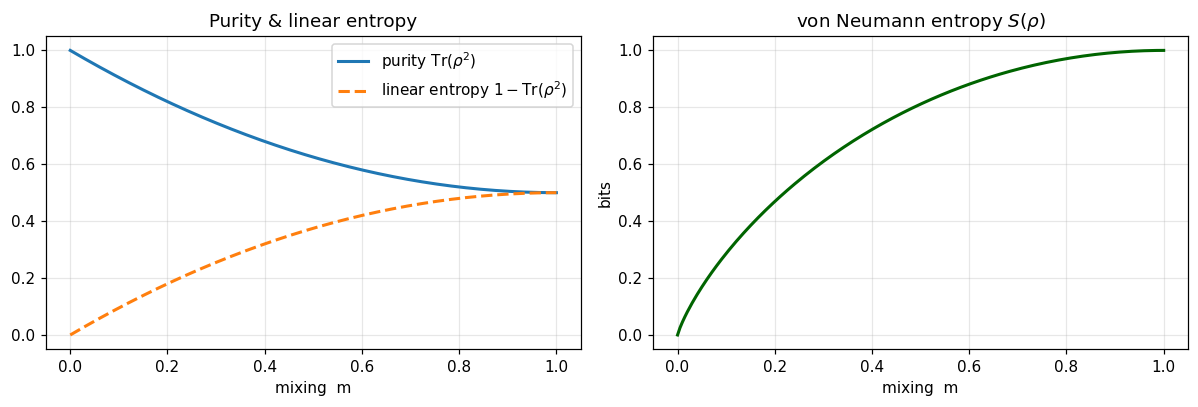

m=0 -> pure |+>  (purity 1, entropy 0);   m=1 -> I/2  (purity 1/2, entropy 1 bit).


In [ ]:
xs = np.linspace(0,1,200)   # mixing parameter m: rho = (1-m)|+><+| + m I/2
pur, vn, lin = [], [], []
for m in xs:
    rho = (1-m)*density_from_state(ketp) + m*(I2/2)
    pur.append(purity(rho)); vn.append(von_neumann_entropy(rho)); lin.append(1-purity(rho))

fig, ax = plt.subplots(1,2, figsize=(11,3.8))
ax[0].plot(xs, pur, lw=2, label=r"purity $\mathrm{Tr}(\rho^2)$")
ax[0].plot(xs, lin, lw=2, ls="--", label=r"linear entropy $1-\mathrm{Tr}(\rho^2)$")
ax[0].set_xlabel("mixing  m"); ax[0].set_title("Purity & linear entropy"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(xs, vn, lw=2, color="darkgreen")
ax[1].set_xlabel("mixing  m"); ax[1].set_ylabel("bits"); ax[1].set_title(r"von Neumann entropy $S(\rho)$"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print("m=0 -> pure |+>  (purity 1, entropy 0);   m=1 -> I/2  (purity 1/2, entropy 1 bit).")

### 2.4 Interactive: watch the Bloch vector shrink as a state mixes

Drag the slider. As the mixing parameter $m$ grows, the Bloch vector **retracts toward the centre**, the purity falls from $1$ toward $\tfrac12$, and the entropy climbs from $0$ to $1$ bit. *(In Colab the slider is live; in a static export the default frame is shown.)*

In [ ]:
from ipywidgets import interact, FloatSlider

def mix_demo(m=0.0):
    rho = (1-m)*density_from_state(ketp) + m*(I2/2)
    r = bloch_vector(rho)
    fig = plt.figure(figsize=(4.6,4.6)); ax = fig.add_subplot(111, projection="3d")
    plot_bloch(r, ax=ax,
               title=f"m={m:.2f}   |r|={np.linalg.norm(r):.2f}\npurity={purity(rho):.2f}   S={von_neumann_entropy(rho):.2f} bit")
    plt.show()

try:
    interact(mix_demo, m=FloatSlider(min=0, max=1, step=0.05, value=0.0))
except Exception as e:
    mix_demo(0.4)   # static fallback
    print("(interactive widgets unavailable here; showing a static frame)")

interactive(children=(FloatSlider(value=0.0, description='m', max=1.0, step=0.05), Output()), _dom_classes=('w…

## 3 · Coherence - the off-diagonal part of a qubit

### 3.1 Populations vs. coherences

In a fixed basis (say computational $\{|0\rangle,|1\rangle\}$) write

$$\rho = \begin{pmatrix} \rho_{00} & \rho_{01}\\ \rho_{10} & \rho_{11}\end{pmatrix}.$$

- The **diagonal** entries $\rho_{00},\rho_{11}$ are **populations** - the probabilities of measuring $0$ or $1$.
- The **off-diagonal** entries $\rho_{01}=\rho_{10}^{*}$ are **coherences** - they encode the *definite phase relationship* between $|0\rangle$ and $|1\rangle$ that makes interference possible.

Kill the off-diagonals and you are left with a classical probability distribution over $0$ and $1$: a coin, not a superposition.

### 3.2 Coherence is **basis-dependent** (purity is not)

This is the conceptual heart of the section. $|+\rangle$ is *brimming* with coherence in the $Z$ basis but is a plain *eigenstate* (zero coherence) in the $X$ basis. Purity is an intrinsic, basis-independent number; **coherence is a statement about a chosen measurement basis.** A convenient measure is the **$\ell_1$-norm of coherence**

$$C_{\ell_1}(\rho) = \sum_{i\neq j} |\rho_{ij}|.$$

In [ ]:
rho_plus = density_from_state(ketp)
print("|+> in the Z (computational) basis:")
print(rho_plus, f"\n   l1-coherence = {l1_coherence(rho_plus):.3f}  (off-diagonals present)\n")

# change basis to the X eigenbasis {|+>,|->} via H (Hadamard)
H = (1/np.sqrt(2))*np.array([[1,1],[1,-1]], dtype=complex)
rho_plus_xbasis = H @ rho_plus @ H.conj().T
print("The SAME state |+> expressed in the X basis:")
print(np.round(rho_plus_xbasis,6), f"\n   l1-coherence = {l1_coherence(rho_plus_xbasis):.3f}  (now diagonal!)")
print(f"\nPurity is unchanged either way: {purity(rho_plus):.3f} vs {purity(rho_plus_xbasis):.3f}")

|+> in the Z (computational) basis:
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]] 
   l1-coherence = 1.000  (off-diagonals present)

The SAME state |+> expressed in the X basis:
[[ 1.+0.j  0.+0.j]
 [-0.+0.j -0.+0.j]] 
   l1-coherence = 0.000  (now diagonal!)

Purity is unchanged either way: 1.000 vs 1.000


### 3.3 Decoherence: the off-diagonals vanishing

A **dephasing** process randomises the relative phase between $|0\rangle$ and $|1\rangle$. As a quantum channel,

$$\mathcal{E}_p(\rho) = \big(1-\tfrac{p}{2}\big)\rho + \tfrac{p}{2}\,Z\rho Z,$$

which leaves populations untouched but shrinks coherences: $\rho_{01}\to(1-p)\,\rho_{01}$. Over continuous time this is the familiar $\rho_{01}(t) = \rho_{01}(0)\,e^{-t/T_2}$ - the **dephasing spiral** from Notebook 3.

**Why a physicist should care:** the off-diagonals are *precisely* what produce interference fringes. When they decay, the double-slit pattern washes out and the SG erasure experiment stops showing revival. Decoherence is the quantitative statement of *"which-path information destroys interference."* In §6 we'll see **where that information goes.**

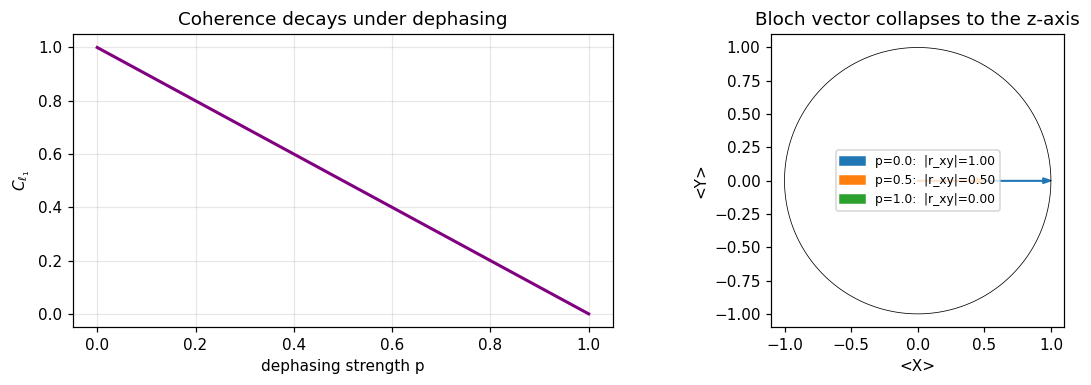

In [ ]:
def dephasing_channel(rho, p):
    """Dephasing: populations fixed, coherence rho_01 -> (1-p) rho_01."""
    return (1 - p/2)*rho + (p/2)*(Z @ rho @ Z)

ts = np.linspace(0, 1, 60)        # p plays the role of "how much dephasing"
rho0 = density_from_state(ketp)
coh  = [l1_coherence(dephasing_channel(rho0, p)) for p in ts]

fig, ax = plt.subplots(1,2, figsize=(11,3.6))
ax[0].plot(ts, coh, lw=2, color="purple")
ax[0].set_xlabel("dephasing strength p"); ax[0].set_ylabel(r"$C_{\ell_1}$")
ax[0].set_title("Coherence decays under dephasing"); ax[0].grid(alpha=.3)

# show the matrix at three stages
for p, c in zip([0.0, 0.5, 1.0], ["#1f77b4","#ff7f0e","#2ca02c"]):
    r = bloch_vector(dephasing_channel(rho0, p))
    ax[1].arrow(0,0, r[0], r[1], head_width=0.04, color=c, length_includes_head=True,
                label=f"p={p}:  |r_xy|={np.hypot(r[0],r[1]):.2f}")
th = np.linspace(0,2*np.pi,200); ax[1].plot(np.cos(th), np.sin(th), 'k-', lw=.5)
ax[1].set_aspect('equal'); ax[1].set_xlim(-1.1,1.1); ax[1].set_ylim(-1.1,1.1)
ax[1].set_xlabel("<X>"); ax[1].set_ylabel("<Y>"); ax[1].legend(fontsize=8)
ax[1].set_title("Bloch vector collapses to the z-axis")
plt.tight_layout(); plt.show()

## 4 · Multiqubit systems - the tensor product

### 4.1 Composing Hilbert spaces

Two qubits $A$ and $B$ live in the **tensor-product** space

$$\mathcal H_{AB} = \mathcal H_A \otimes \mathcal H_B, \qquad \dim = 2\times 2 = 4.$$

The computational basis is $\{|00\rangle,|01\rangle,|10\rangle,|11\rangle\}$, where $|ij\rangle \equiv |i\rangle_A\otimes|j\rangle_B$. A general two-qubit pure state is

$$|\psi\rangle = c_{00}|00\rangle + c_{01}|01\rangle + c_{10}|10\rangle + c_{11}|11\rangle, \qquad \sum |c_{ij}|^2 = 1.$$

Numerically the tensor product is the **Kronecker product** `np.kron`. Crucially the dimension grows as $2^n$ - *this exponential state space is the resource quantum computers exploit.*

### 4.2 Operators on a composite system

An operator acting on the pair is $A\otimes B$. A gate applied to **qubit $A$ only** is $A\otimes I$ - it acts as the identity on $B$. This is how we build local operations.

In [ ]:
def kron(*ops):
    """Kronecker product of any number of vectors/matrices."""
    out = ops[0]
    for o in ops[1:]:
        out = np.kron(out, o)
    return out

# computational basis of two qubits
ket00, ket01 = kron(ket0,ket0), kron(ket0,ket1)
ket10, ket11 = kron(ket1,ket0), kron(ket1,ket1)
print("|01> as a 4-vector (ordering |00>,|01>,|10>,|11>):")
print(ket01.ravel().real)

# a product state |+> (x) |0>
prod = kron(ketp, ket0)
print("\nProduct state |+>|0> :", np.round(prod.ravel(),3))

# local operator: apply X to qubit A only  ==  X (x) I
XA = kron(X, I2)
print("\n(X(x)I)|0>|0>  should give |1>|0> = |10> :",
      np.round((XA @ ket00).ravel().real))

|01> as a 4-vector (ordering |00>,|01>,|10>,|11>):
[0. 1. 0. 0.]

Product state |+>|0> : [0.707+0.j 0.   +0.j 0.707+0.j 0.   +0.j]

(X(x)I)|0>|0>  should give |1>|0> = |10> : [0. 0. 1. 0.]


## 5 · Entanglement

### 5.1 Separable vs. entangled

A pure two-qubit state is **separable** (a *product* state) if it factorises:

$$|\psi\rangle = |a\rangle_A \otimes |b\rangle_B.$$

If **no** such factorisation exists, the state is **entangled**. The canonical maximally entangled states are the four **Bell states**:

$$|\Phi^\pm\rangle = \tfrac{1}{\sqrt2}\big(|00\rangle \pm |11\rangle\big), \qquad
|\Psi^\pm\rangle = \tfrac{1}{\sqrt2}\big(|01\rangle \pm |10\rangle\big).$$

**Why is $|\Phi^+\rangle$ not a product?** Suppose $|\Phi^+\rangle = (a|0\rangle+b|1\rangle)\otimes(c|0\rangle+d|1\rangle)$. Matching coefficients needs $ac=bd=\tfrac1{\sqrt2}$ but $ad=bc=0$. The second pair forces one of $a,b,c,d$ to vanish, which then kills one of the first two - a contradiction. No factorisation exists. $\;\blacksquare$

In [ ]:
bell = {
 "Phi+": (kron(ket0,ket0)+kron(ket1,ket1))/np.sqrt(2),
 "Phi-": (kron(ket0,ket0)-kron(ket1,ket1))/np.sqrt(2),
 "Psi+": (kron(ket0,ket1)+kron(ket1,ket0))/np.sqrt(2),
 "Psi-": (kron(ket0,ket1)-kron(ket1,ket0))/np.sqrt(2),
}
print("The four Bell states (coefficients on |00>,|01>,|10>,|11>):")
for name, v in bell.items():
    print(f"  |{name}> = {np.round(v.ravel(),3)}")

# orthonormality: they form a complete basis of the 2-qubit space
M = np.hstack([v for v in bell.values()])
print("\nDo they form an orthonormal basis?  M^dag M = I :",
      np.allclose(M.conj().T @ M, np.eye(4)))

The four Bell states (coefficients on |00>,|01>,|10>,|11>):
  |Phi+> = [0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]
  |Phi-> = [ 0.707+0.j  0.   +0.j  0.   +0.j -0.707+0.j]
  |Psi+> = [0.   +0.j 0.707+0.j 0.707+0.j 0.   +0.j]
  |Psi-> = [ 0.   +0.j  0.707+0.j -0.707+0.j  0.   +0.j]

Do they form an orthonormal basis?  M^dag M = I : True


### 5.2 The partial trace and the reduced density matrix

If we hold the pair in state $\rho_{AB}$ but only have access to qubit $A$, what is *its* state? We **trace out** $B$:

$$\rho_A = \mathrm{Tr}_B(\rho_{AB}), \qquad \mathrm{Tr}_B\big(|a_1\rangle\langle a_2|\otimes|b_1\rangle\langle b_2|\big) = |a_1\rangle\langle a_2|\;\langle b_2|b_1\rangle.$$

This is the quantum analogue of a **marginal distribution**: it answers every question about $A$ alone, correctly accounting for our ignorance of $B$.

In [ ]:
def partial_trace(rho, keep, dims=(2,2)):
    """Reduce a bipartite density matrix.
       keep=0 -> trace out B, return rho_A;  keep=1 -> trace out A, return rho_B."""
    dA, dB = dims
    t = rho.reshape(dA, dB, dA, dB)          # <i j| rho |k l>
    if keep == 0:
        return np.trace(t, axis1=1, axis2=3)  # sum over B index
    else:
        return np.trace(t, axis1=0, axis2=2)  # sum over A index

# sanity check on a product state: rho_A should be exactly |+><+|
rho_prod = density_from_state(kron(ketp, ket0))
print("Product |+>|0> -> rho_A =\n", np.round(partial_trace(rho_prod, 0),4))
print("  purity(rho_A) =", round(purity(partial_trace(rho_prod,0)),4), "(pure: nothing lost)")

Product |+>|0> -> rho_A =
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]
  purity(rho_A) = 1.0 (pure: nothing lost)


### 5.3 The key theorem: entanglement $\iff$ a mixed reduced state

> **Theorem.** A *pure* bipartite state $|\psi\rangle_{AB}$ is **entangled if and only if** its reduced state $\rho_A$ is **mixed** ($\mathrm{Tr}(\rho_A^2)<1$).

This binds together everything in this notebook. For the Bell state $|\Phi^+\rangle$:

$$\rho_A = \mathrm{Tr}_B|\Phi^+\rangle\langle\Phi^+| = \tfrac12 I.$$

The pair is in a perfectly definite, pure state - we know *everything* about the two qubits together - yet **each qubit alone is maximally mixed.** The information lives entirely in the *correlations*, not in the parts. This is the precise sense in which entanglement is "more than the sum of its parts."

The amount of entanglement (for a pure bipartite state) is the **entanglement entropy** $S(\rho_A)$ - exactly the von Neumann entropy of the reduced state. Bell states give $S=1$ bit (maximal); product states give $S=0$.

In [ ]:
print(f"{'state':14s}{'purity(rho_A)':>15s}{'S(rho_A) bits':>16s}{'verdict':>16s}")
print("-"*61)
examples = {
  "|+>|0> product": kron(ketp, ket0),
  "|0>|1> product ": kron(ket0, ket1),
  "Bell |Phi+>    ": bell["Phi+"],
  "Bell |Psi->    ": bell["Psi-"],
}
for name, psi in examples.items():
    rhoA = partial_trace(density_from_state(psi), 0)
    p, S = purity(rhoA), von_neumann_entropy(rhoA)
    verdict = "ENTANGLED" if p < 0.999 else "separable"
    print(f"{name:14s}{p:>15.4f}{S:>16.4f}{verdict:>16s}")

state           purity(rho_A)   S(rho_A) bits         verdict
-------------------------------------------------------------
|+>|0> product         1.0000         -0.0000       separable
|0>|1> product          1.0000         -0.0000       separable
Bell |Phi+>             0.5000          1.0000       ENTANGLED
Bell |Psi->             0.5000          1.0000       ENTANGLED


### 5.4 Schmidt decomposition - the canonical form

Any bipartite pure state can be written, after choosing the right local bases, as a **single sum**

$$|\psi\rangle = \sum_{i} \sqrt{\lambda_i}\;|i\rangle_A \otimes |i\rangle_B, \qquad \lambda_i \ge 0,\ \sum_i\lambda_i = 1.$$

The $\sqrt{\lambda_i}$ are the **Schmidt coefficients** (the singular values of the coefficient matrix $C_{ij}$), and the number of non-zero terms is the **Schmidt rank**:

- **Schmidt rank $1$ $\iff$ separable** (a single product term),
- **Schmidt rank $>1$ $\iff$ entangled.**

The $\lambda_i$ are exactly the eigenvalues of $\rho_A$, so the entanglement entropy is $S=-\sum_i\lambda_i\log_2\lambda_i$. We compute the Schmidt coefficients with a singular-value decomposition of the $2\times2$ coefficient matrix.

In [ ]:
def schmidt_coeffs(psi, dims=(2,2)):
    """Schmidt coefficients (singular values) of a bipartite pure state."""
    C = np.asarray(psi, dtype=complex).reshape(dims)
    return np.linalg.svd(C, compute_uv=False)

def entanglement_entropy(psi, dims=(2,2)):
    s = schmidt_coeffs(psi, dims); lam = s**2
    lam = lam[lam > 1e-12]
    return float(-np.sum(lam*np.log2(lam)))

for name, psi in examples.items():
    s = schmidt_coeffs(psi)
    rank = int(np.sum(s > 1e-9))
    print(f"{name:14s} Schmidt coeffs = {np.round(s,3)}  rank = {rank}  "
          f"E = {entanglement_entropy(psi):.3f} bits")

|+>|0> product Schmidt coeffs = [1. 0.]  rank = 1  E = -0.000 bits
|0>|1> product  Schmidt coeffs = [1. 0.]  rank = 1  E = -0.000 bits
Bell |Phi+>     Schmidt coeffs = [0.707 0.707]  rank = 2  E = 1.000 bits
Bell |Psi->     Schmidt coeffs = [0.707 0.707]  rank = 2  E = 1.000 bits


### 5.5 Interactive: tuning from product to maximally entangled

The family

$$|\psi(\theta)\rangle = \cos\theta\,|00\rangle + \sin\theta\,|11\rangle$$

interpolates from a **product** state ($\theta=0$, gives $|00\rangle$) through partial entanglement to the **maximally entangled** $|\Phi^+\rangle$ at $\theta=\tfrac\pi4$. Watch the reduced-state purity fall and the entanglement entropy rise together.

In [ ]:
from ipywidgets import interact, FloatSlider

def ent_demo(theta=0.0):
    psi = np.cos(theta)*ket00 + np.sin(theta)*ket11
    rhoA = partial_trace(density_from_state(psi), 0)
    s = schmidt_coeffs(psi)
    fig, ax = plt.subplots(1,2, figsize=(10,3.4))
    ax[0].bar(["lambda_0","lambda_1"], s**2, color=["#3366cc","#cc6633"])
    ax[0].set_ylim(0,1); ax[0].set_title("Schmidt weights  (eigenvalues of rho_A)")
    th = np.linspace(0,np.pi/4,100)
    ax[1].plot(th, [1-purity(partial_trace(density_from_state(np.cos(t)*ket00+np.sin(t)*ket11),0)) for t in th],
               label="linear entropy of rho_A")
    ax[1].plot(th, [entanglement_entropy(np.cos(t)*ket00+np.sin(t)*ket11) for t in th],
               label="entanglement entropy (bits)")
    ax[1].axvline(theta, color="k", ls=":"); ax[1].legend(fontsize=8)
    ax[1].set_xlabel("theta"); ax[1].set_title(f"theta={theta:.2f}  E={entanglement_entropy(psi):.3f} bit")
    plt.tight_layout(); plt.show()

try:
    interact(ent_demo, theta=FloatSlider(min=0, max=np.pi/4, step=np.pi/40, value=0.0))
except Exception:
    ent_demo(np.pi/8)
    print("(interactive widgets unavailable here; showing a static frame)")

interactive(children=(FloatSlider(value=0.0, description='theta', max=0.7853981633974483, step=0.0785398163397…

## 6 · Synthesis - *decoherence is entanglement with the environment*

We can now close the loop on the double-slit / Stern–Gerlach thread that runs through this whole course.

**The setup.** Take a "system" qubit in the superposition $|+\rangle$ and a "detector" (or environment) qubit that will try to *record which path* the system took. Let them interact through a **controlled rotation** of strength $\theta$, which copies a $\theta$-amount of which-path information into the detector:

$$|+\rangle_S|0\rangle_D \;\longrightarrow\; \tfrac{1}{\sqrt2}\Big(|0\rangle_S|0\rangle_D + |1\rangle_S\big(\cos\theta\,|0\rangle_D + \sin\theta\,|1\rangle_D\big)\Big).$$

- At $\theta=0$ the detector learns nothing - the system stays pure $|+\rangle$, **full coherence, no entanglement.**
- At $\theta=\tfrac\pi2$ the detector perfectly records the path - the joint state becomes the **Bell state** $|\Phi^+\rangle$, and the system's reduced state collapses to $\tfrac12 I$: **zero coherence, maximal entanglement.**

A direct calculation gives the system's coherence as $|\rho^S_{01}| = \tfrac{\cos\theta}{2}$. **The coherence the system loses is exactly the entanglement it gains with the detector.** Interference does not vanish by magic when "we look" - it migrates into correlations with whatever did the looking.

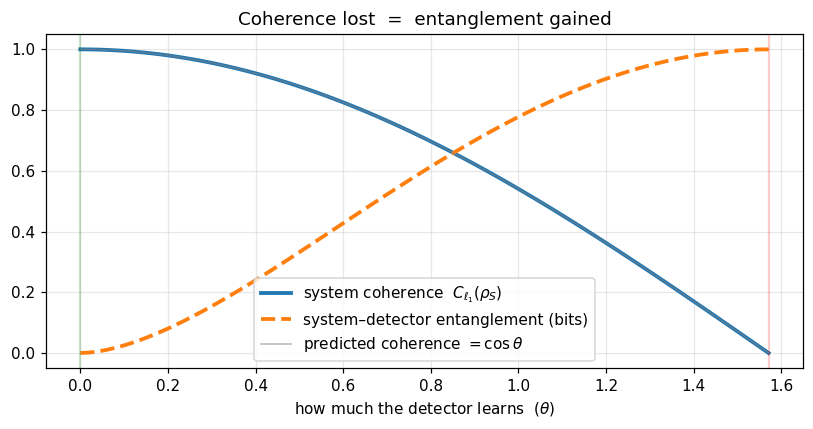

theta=0   : pure |+>, an interference-capable superposition, no which-path record.
theta=pi/2: Bell state; the system alone is I/2 -> no interference, full which-path record.


In [ ]:
thetas = np.linspace(0, np.pi/2, 80)
coh_sys, ent = [], []
for th in thetas:
    psi = (kron(ket0,ket0) + np.cos(th)*kron(ket1,ket0) + np.sin(th)*kron(ket1,ket1))/np.sqrt(2)
    rhoS = partial_trace(density_from_state(psi), 0)
    coh_sys.append(l1_coherence(rhoS))
    ent.append(entanglement_entropy(psi))

fig, ax = plt.subplots(figsize=(7.5,4))
ax.plot(thetas, coh_sys, lw=2.5, label=r"system coherence  $C_{\ell_1}(\rho_S)$")
ax.plot(thetas, ent,     lw=2.5, ls="--", label="system–detector entanglement (bits)")
ax.plot(thetas, np.cos(thetas), lw=1, color="gray", alpha=.6, label=r"predicted coherence $=\cos\theta$")
ax.set_xlabel(r"how much the detector learns  ($\theta$)")
ax.set_title("Coherence lost  =  entanglement gained")
ax.axvline(0, color="green", alpha=.2); ax.axvline(np.pi/2, color="red", alpha=.2)
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print("theta=0   : pure |+>, an interference-capable superposition, no which-path record.")
print("theta=pi/2: Bell state; the system alone is I/2 -> no interference, full which-path record.")

## 7 · Exercises

Try each before opening the solution. Difficulty: ★ (warm-up) · ★★ (core) · ★★★ (synthesis). To reveal a solution, run its cell.

**E1.** Compute the purity and Bloch-vector length of $\rho = \tfrac34|0\rangle\langle0| + \tfrac14|1\rangle\langle1|$. Is it pure?

**E2.** Show by direct computation that $|-i\rangle\langle -i|$ has coherence in the $Z$ basis but is diagonal in the $Y$ basis.

**E3.** Compute $\rho_B$ (trace out $A$) for $|\Psi^-\rangle$. What is its purity, and what does that tell you?

**E4.** Verify numerically that the state $|\psi\rangle = \tfrac{1}{\sqrt3}|00\rangle + \sqrt{\tfrac23}\,|11\rangle$ is entangled, and report its entanglement entropy.

**E5.** Construct a two-qubit pure state whose entanglement entropy is exactly $0.5$ bit. (Hint: solve $-\lambda\log_2\lambda-(1-\lambda)\log_2(1-\lambda)=0.5$ for $\lambda$, then use $\sqrt\lambda|00\rangle+\sqrt{1-\lambda}|11\rangle$.)

**E6.** In the §6 model, prove numerically that *system coherence* $+$ *information gained by the detector* are two sides of one coin: plot detector "distinguishability" $D(\theta)=\sin\theta$ against system coherence and confirm $C_{\ell_1}^2 + D^2 = 1$ (a coherence–distinguishability duality).

In [ ]:
#@title ★ E1 solution
rho = 0.75*density_from_state(ket0) + 0.25*density_from_state(ket1)
r = bloch_vector(rho)
print(f"purity = {purity(rho):.4f}  (<1, so MIXED)")
print(f"|r| = {np.linalg.norm(r):.4f}   check (1+|r|^2)/2 = {(1+np.dot(r,r))/2:.4f}")

purity = 0.6250  (<1, so MIXED)
|r| = 0.5000   check (1+|r|^2)/2 = 0.6250


In [ ]:
#@title ★ E2 solution
ket_mi = (ket0 - 1j*ket1)/np.sqrt(2)        # |-i>
rho = density_from_state(ket_mi)
print("In Z basis:\n", np.round(rho,3), " l1 =", round(l1_coherence(rho),3))
# Y eigenbasis change: columns are |+i>,|-i>
V = np.hstack([keti, ket_mi])
rho_y = V.conj().T @ rho @ V
print("\nIn Y basis:\n", np.round(rho_y,3), " l1 =", round(l1_coherence(rho_y),3), "(diagonal)")

In Z basis:
 [[0.5+0.j  0. +0.5j]
 [0. -0.5j 0.5+0.j ]]  l1 = 1.0

In Y basis:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]  l1 = 0.0 (diagonal)


In [ ]:
#@title ★★ E3 solution
psi = bell["Psi-"]
rhoB = partial_trace(density_from_state(psi), keep=1)
print("rho_B =\n", np.round(rhoB,4))
print("purity =", round(purity(rhoB),4), "-> maximally mixed -> |Psi-> is maximally entangled.")

rho_B =
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
purity = 0.5 -> maximally mixed -> |Psi-> is maximally entangled.


In [ ]:
#@title ★★ E4 solution
psi = (1/np.sqrt(3))*ket00 + np.sqrt(2/3)*ket11
rhoA = partial_trace(density_from_state(psi),0)
print("Schmidt coeffs:", np.round(schmidt_coeffs(psi),4), "-> rank 2 -> ENTANGLED")
print("purity(rho_A) =", round(purity(rhoA),4), "(<1)")
print("entanglement entropy =", round(entanglement_entropy(psi),4), "bits")

Schmidt coeffs: [0.8165 0.5774] -> rank 2 -> ENTANGLED
purity(rho_A) = 0.5556 (<1)
entanglement entropy = 0.9183 bits


In [ ]:
#@title ★★★ E5 solution
# Solve H(lambda) = 0.5 by bisection (no scipy).
def Hbin(l):
    if l<=0 or l>=1: return 0.0
    return -l*np.log2(l)-(1-l)*np.log2(1-l)
lo, hi = 1e-6, 0.5
for _ in range(60):
    mid = (lo+hi)/2
    if Hbin(mid) < 0.5: lo = mid
    else: hi = mid
lam = mid
psi = np.sqrt(lam)*ket00 + np.sqrt(1-lam)*ket11
print(f"lambda = {lam:.5f}")
print(f"entanglement entropy of constructed state = {entanglement_entropy(psi):.5f} bits  (target 0.5)")

lambda = 0.11003
entanglement entropy of constructed state = 0.50000 bits  (target 0.5)


max |C^2 + D^2 - 1| = 4.440892098500626e-16   (=> C^2 + D^2 = 1)


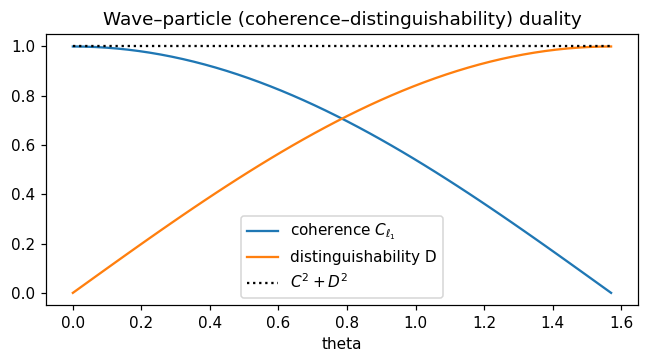

In [ ]:
#@title ★★★ E6 solution
th = np.linspace(0, np.pi/2, 50)
C, D = [], []
for t in th:
    psi = (kron(ket0,ket0)+np.cos(t)*kron(ket1,ket0)+np.sin(t)*kron(ket1,ket1))/np.sqrt(2)
    C.append(l1_coherence(partial_trace(density_from_state(psi),0)))
    D.append(np.sin(t))                 # which-path distinguishability
C, D = np.array(C), np.array(D)
print("max |C^2 + D^2 - 1| =", np.max(np.abs(C**2 + D**2 - 1)), "  (=> C^2 + D^2 = 1)")
plt.figure(figsize=(6,3.4))
plt.plot(th, C, label=r"coherence $C_{\ell_1}$"); plt.plot(th, D, label="distinguishability D")
plt.plot(th, C**2+D**2, 'k:', label=r"$C^2+D^2$")
plt.xlabel("theta"); plt.legend(); plt.title("Wave–particle (coherence–distinguishability) duality")
plt.tight_layout(); plt.show()

## 8 · In Summary

We now hold the full single- and two-qubit toolkit:

- $\rho$, its validity conditions, and $\langle A\rangle=\mathrm{Tr}(\rho A)$;
- **purity** $\mathrm{Tr}(\rho^2)$ as the Bloch radius, and **entropy** as ignorance;
- **Coherence** as basis-dependent off-diagonals, and **dephasing** as their decay;
- **Tensor products** for composite systems;
- **Partial trace**, **reduced states**, **Schmidt decomposition**, and **entanglement entropy**;
- The unifying picture: *decoherence is entanglement with an inaccessible system.*